<a href="https://colab.research.google.com/github/scorpgal03-eng/Python-AI/blob/main/Assignment_template.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Assignment: The Autonomous IT Support Agent**

This is a coding assignment for the **Level 1 IT Incident Responder**.

This assignment assumes the learners have the `openai` library installed and an API key ready and stored in the variable name `OPENAI_APIKEY` as a notebook secret variable and enabled

---

**Objective:** You are building an AI agent that acts as the "first responder" for server incidents. It must:

1. **Investigate:** Check server health and logs when a user reports an issue.
2. **Act:** If CPU is critical (>90%), it should **Restart** the service.
3. **Escalate:** If the issue is complex or logs show a major problem it should **Escalate** to a human.

**Your Task:** complete the code below by filling in the sections marked `### TODO`.

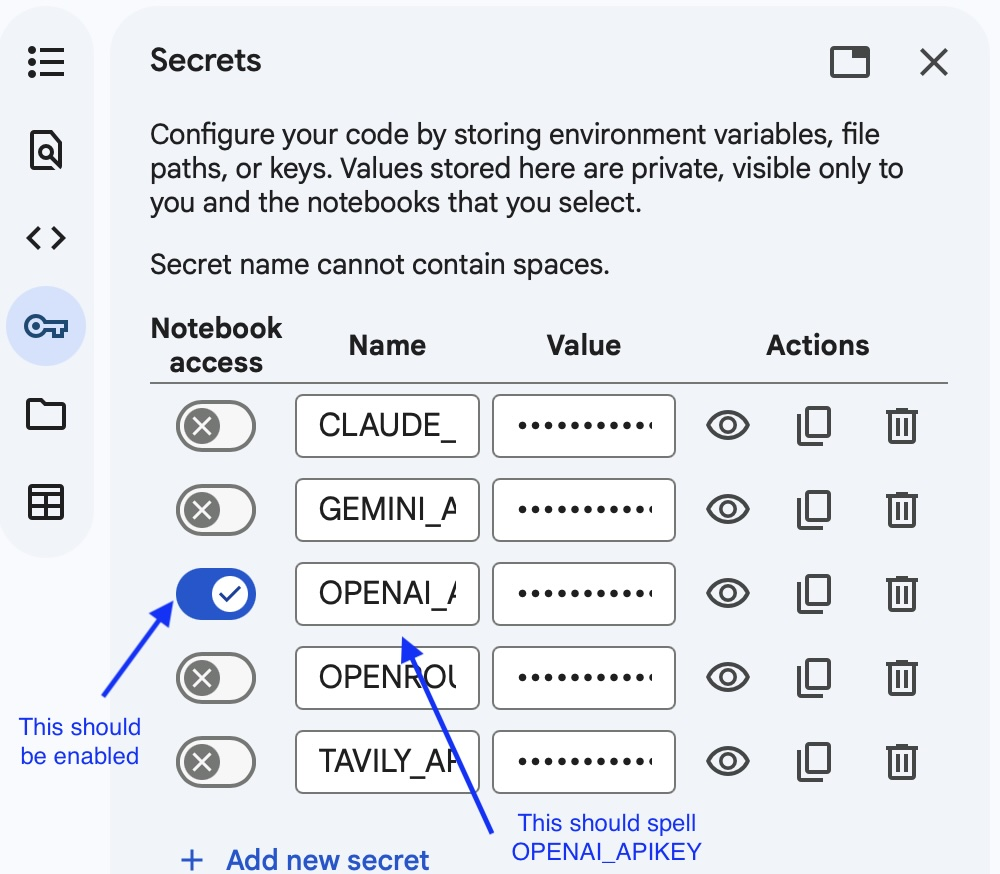

In [1]:
import os
import json
from openai import OpenAI
from google.colab import userdata

In [2]:
client = OpenAI(api_key=userdata.get('OPENAI_APIKEY'))

# Initialize Client

==========================================
## PART 1: DEFINE THE TOOLS (BUSINESS LOGIC)
==========================================

In [28]:
# --- Already implement tool 1: Check Health ---
def get_server_health(server_id: str) -> str:
    """Returns CPU and Memory usage for a given server."""
    print(f"-> TOOL: Checking health for {server_id}...")

    metrics = {
        # Scenario 1: High CPU (Needs Restart)
        "payment-server-01": {"cpu": "98%", "memory": "40%", "status": "Warning"},

        # Scenario 2: Healthy (No Action Needed)
        "db-node-02": {"cpu": "12%", "memory": "60%", "status": "Healthy"},

        # Scenario 3: High Memory Leak (Needs Restart or Escalation)
        "auth-service-03": {"cpu": "45%", "memory": "95%", "status": "Critical"},

        # Scenario 4: Network/Dependency Failure (Needs Escalation)
        "search-index-09": {"cpu": "10%", "memory": "15%", "status": "Error"},

        # Scenario 5: Completely Normal
        "frontend-node-04": {"cpu": "25%", "memory": "30%", "status": "Healthy"},
    }

    result = metrics.get(server_id, {"error": "Server not found. Check the ID."})
    return json.dumps(result)


In [29]:
def fetch_recent_logs(server_id: str, lines: int = 5) -> str:
    """Returns the last N lines of logs."""
    print(f"-> TOOL: Fetching last {lines} log lines for {server_id}...")

    # Different logs for different servers to trigger different agent behaviors
    log_database = {
        "payment-server-01": [
            "[INFO] Request received /pay/v1",
            "[WARN] CPU threshold exceeded 90%",
            "[WARN] Thread pool exhaustion",
            "[CRITICAL] Process hung, not accepting new connections",
            "[ERROR] Timeout waiting for thread"
        ],
        "db-node-02": [
            "[INFO] Backup started",
            "[INFO] Backup completed successfully",
            "[INFO] User query executed in 12ms",
            "[INFO] Health check: OK",
            "[INFO] Replication sync active"
        ],
        "auth-service-03": [
            "[INFO] Token validated user_882",
            "[WARN] Garbage collection taking too long (>5s)",
            "[ERROR] java.lang.OutOfMemoryError: Java heap space",
            "[CRITICAL] Application crashing due to memory leak",
            "[INFO] Restarting context..."
        ],
        "search-index-09": [
            "[INFO] Indexing started",
            "[ERROR] Connection refused: elastic-cluster-main:9200",
            "[ERROR] Failed to write document ID 4432",
            "[CRITICAL] Dependency Unreachable: Search Engine is down",
            "[ERROR] Retrying in 30s..."
        ],
        "frontend-node-04": [
            "[INFO] GET /home 200 OK",
            "[INFO] GET /assets/logo.png 200 OK",
            "[INFO] GET /login 200 OK",
            "[INFO] GET /api/v1/status 200 OK",
            "[INFO] Health check passed"
        ]
    }

    # Default logs if server not found in specific list
    default_logs = ["[INFO] System stable", "[INFO] Heartbeat signal received"]

    logs = log_database.get(server_id, default_logs)
    return json.dumps({"logs": logs[:lines]})

---
### ----- Implement code below -----
---


In [30]:
# --- TASK 1: Implement the Restart Tool ---
def restart_service(server_id: str) -> str:
    """
    ### TODO: Implement this function.
    1. Print a message saying "-> TOOL: Restarting service..."
    2. Return a JSON string confirming the restart was successful.
       Example return: '{"status""message": "Server restarted successfully"}'
    """

    print("TOOL: Restarting service for {server_id}...")
    result = {
        "server_id": server_id,
        "status": "success",
        "message": "Server restarted successfully"
    }
    return json.dumps(result)


In [31]:
# --- TASK 2: Implement the Escalation Tool ---
def escalate_to_engineer(summary: str) -> str:
    """
    ### TODO: Implement this function.
    1. Print a message saying "-> TOOL: Escalating to human..."
    2. Return a JSON string confirming the ticket was created.
    """

    print(f"-> TOOL: Escalating to human for reason: {summary}")
    result = {
        "status": "escalated",
        "ticket_no": "INC-999",
        "assigned_to": "On-Call Engineer",
        "summary": summary # Corrected: Removed curly braces around summary
    }
    return json.dumps(result)

In [32]:
# Map functions for the agent execution loop
AVAILABLE_FUNCTIONS = {
    "get_server_health": get_server_health,
    "fetch_recent_logs": fetch_recent_logs,
    "restart_service": restart_service,
    "escalate_to_engineer": escalate_to_engineer,
}

==========================================
## PART 2: DEFINE THE AGENT SCHEMA
==========================================


In [33]:
tools_schema = [
    {
        "type": "function",
        "function": {
            "name": "get_server_health",
            "description": "Checks the current CPU and memory usage of a specific server.",
            "parameters": {
                "type": "object",
                "properties": {
                    "server_id": {"type": "string", "description": "The ID of the server, e.g., 'payment-server-01'"}
                },
                "required": ["server_id"]
            }
        }
    },
    {
        "type": "function",
        "function": {
            "name": "fetch_recent_logs",
            "description": "Retrieves the most recent log entries from a server to diagnose errors.",
            "parameters": {
                "type": "object",
                "properties": {
                    "server_id": {"type": "string", "description": "The ID of the server."},
                    "lines": {"type": "integer", "description": "Number of log lines to fetch."}
                },
                "required": ["server_id"]
            }
        }
    },
    # --- >>>> TASK 3: Define Schema for restart_service ---
    {
        "type": "function",
        "function": {
            "name": "restart_service",
            "description": "Restarts the server service when CPU usage is very high (>90%).",
            "parameters": {
                "type": "object",
                "properties": {
                    "server_id": {"type": "string", "description": "ID of the server to restart."}
                },
                "required": ["server_id"]
            }
        }
    },
    # --- >>>> TASK 4: Define Schema for escalate_to_engineer ---
    {
        "type": "function",
        "function": {
            "name": "escalate_to_engineer",
            "description": "Escalates the issue to a human engineer when automated fixes fail or the error is unknown.",
            "parameters": {
                "type": "object",
                "properties": {
                     "summary": {"type": "string", "description": "A brief summary of findings (health status, error logs) and reason for escalation."}
                },
                "required": ["summary"]
            }
        }
    }
]


 ==========================================
## PART 3: THE AGENT EXECUTION LOOP
 ==========================================


In [34]:
def run_it_agent(user_issue: str):
    print(f"\n--- New Incident: {user_issue} ---")

    messages = [
        {"role": "system", "content": "You are a Level 1 IT Responder. Investigate server issues. "
                                      "If CPU or Memory is > 90%, restart the service. If logs show critical dependency errors (like connection refused) that a restart won't fix, escalate to an engineer."},
        {"role": "user", "content": user_issue}
    ]

    while True:
        print("\n[AI Thinking...]")
        response = client.chat.completions.create(
            model="gpt-4o",
            messages=messages,
            tools=tools_schema,
            tool_choice="auto"
        )

        response_msg = response.choices[0].message
        messages.append(response_msg)

        if response_msg.tool_calls:
            for tool_call in response_msg.tool_calls:
                func_name = tool_call.function.name
                func_args = json.loads(tool_call.function.arguments)

                # Retrieve the actual python function based on name
                function_to_call = AVAILABLE_FUNCTIONS.get(func_name)

                if function_to_call:
                    # Execute the function
                    tool_output = function_to_call(**func_args)

                    # --- TASK 5: Append the result to messages ---
                    # The API needs to know which tool_call_id this output belongs to.
                    # Create the dictionary that represents the "tool" message.

                    messages.append({
                         "role": "tool",
                         "tool_call_id": tool_call.id, # CRITICAL: Links output to the request
                         "name": func_name,         # Links function name
                         "content": tool_output       # Links function output
                     })

                    # [UNCOMMENT AND FIX THE CODE ABOVE]
                    pass # Remove this pass when done

        else:
            print(f"\n[FINAL RESPONSE]: {response_msg.content}")
            break

 ==========================================
## PART 4: TEST SCENARIOS
 ==========================================


In [12]:
# Scenario A: Should trigger a restart (CPU is 98%)
run_it_agent("The payment-server-01 is extremely slow and timing out.")


--- New Incident: The payment-server-01 is extremely slow and timing out. ---

[AI Thinking...]
-> TOOL: Checking health for payment-server-01...
-> TOOL: Fetching last 20 log lines for payment-server-01...

[AI Thinking...]
TOOL: Restarting service for {server_id}...

[AI Thinking...]

[FINAL RESPONSE]: The payment-server-01 was experiencing extremely high CPU usage at 98%, which was causing it to slow down and time out. I have restarted the service successfully, and it should now be operating normally. If the issue persists, please let me know.


In [13]:
# Scenario B: Should trigger an escalation (DB is healthy but logs might be weird)
run_it_agent("Something is wrong with db-node-02")


--- New Incident: Something is wrong with db-node-02 ---

[AI Thinking...]
-> TOOL: Checking health for db-node-02...
-> TOOL: Fetching last 20 log lines for db-node-02...

[AI Thinking...]

[FINAL RESPONSE]: The server `db-node-02` appears to be healthy with a CPU usage of 12% and memory usage of 60%. The recent logs do not show any critical errors; they mostly contain informational messages such as successful backups and health checks.

It seems there are no immediate issues with the server. If you're experiencing specific problems, please provide additional details so that I can assist you further.


In [14]:
# Scenario C: The High Memory Case (auth-service-03)
# Agent should see Memory 95% + OutOfMemoryError logs -> Restart
run_it_agent("Users are reporting login failures on auth-service-03.")

print("\n" + "="*50 + "\n")


--- New Incident: Users are reporting login failures on auth-service-03. ---

[AI Thinking...]
-> TOOL: Checking health for auth-service-03...
-> TOOL: Fetching last 50 log lines for auth-service-03...

[AI Thinking...]
TOOL: Restarting service for {server_id}...

[AI Thinking...]

[FINAL RESPONSE]: The auth-service-03 was experiencing high memory usage (>90%), which is a critical issue, and it resulted in a memory leak leading to application crashes. I have restarted the service, and it successfully restarted. Please check if users are now able to log in again.




In [35]:
# Scenario D: The Dependency Failure (search-index-09)
# Agent should see healthy CPU but "Connection Refused" logs -> Escalate
run_it_agent("Search isn't working. Can you check search-index-09?")

print("\n" + "="*50 + "\n")


--- New Incident: Search isn't working. Can you check search-index-09? ---

[AI Thinking...]
-> TOOL: Checking health for search-index-09...
-> TOOL: Fetching last 10 log lines for search-index-09...

[AI Thinking...]
-> TOOL: Escalating to human for reason: The server 'search-index-09' shows low CPU (10%) and memory (15%) usage, but logs indicate critical errors: 'Connection refused: elastic-cluster-main:9200' and 'Dependency Unreachable: Search Engine is down'. A restart will not resolve this dependency issue.

[AI Thinking...]

[FINAL RESPONSE]: The issue with the search function on server "search-index-09" has been escalated to an engineer. The server's CPU and memory usage are normal, but critical errors in the logs indicate that a dependency issue with the search engine is causing the problem. A support ticket (INC-999) has been created and assigned to the on-call engineer for resolution.




In [16]:
# Scenario E: The Healthy Server (frontend-node-04)
# Agent should see normal stats and 200 OK logs -> Do nothing / Report healthy
run_it_agent("Check frontend-node-04 just to be safe.")


--- New Incident: Check frontend-node-04 just to be safe. ---

[AI Thinking...]
-> TOOL: Checking health for frontend-node-04...
-> TOOL: Fetching last 10 log lines for frontend-node-04...

[AI Thinking...]

[FINAL RESPONSE]: The server "frontend-node-04" is operating normally with the following details:

- **CPU Usage:** 25%
- **Memory Usage:** 30%
- **Health Status:** Healthy

Recent logs show normal activity with successful requests and no errors:

- `[INFO] GET /home 200 OK`
- `[INFO] GET /assets/logo.png 200 OK`
- `[INFO] GET /login 200 OK`
- `[INFO] GET /api/v1/status 200 OK`
- `[INFO] Health check passed`

Everything seems to be in order. No further action is needed.
